<a href="https://colab.research.google.com/github/anshulkr69/learning-to-make-machine-learn/blob/main/8_Function_Tranformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mathematical transformsations
There are many types of mathematical transformation and these come under column transformation.
We need them to get a normal data i.e. a data having a normal distribution or normalPDF, whose peak is centred.


There are many ways to check if the data is normal or not:
1. sns.kdeplot()
2. pd.skew()

and the best way is a QQ Plot:



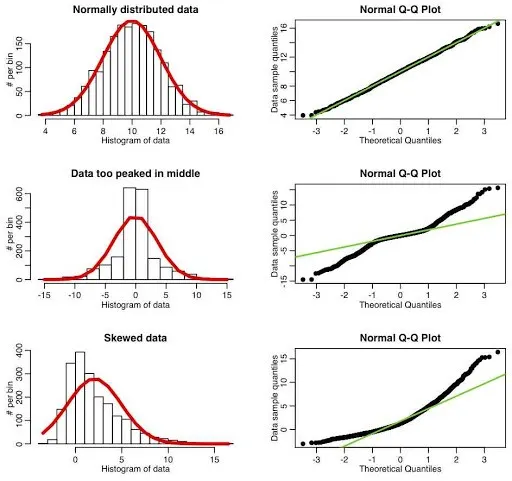
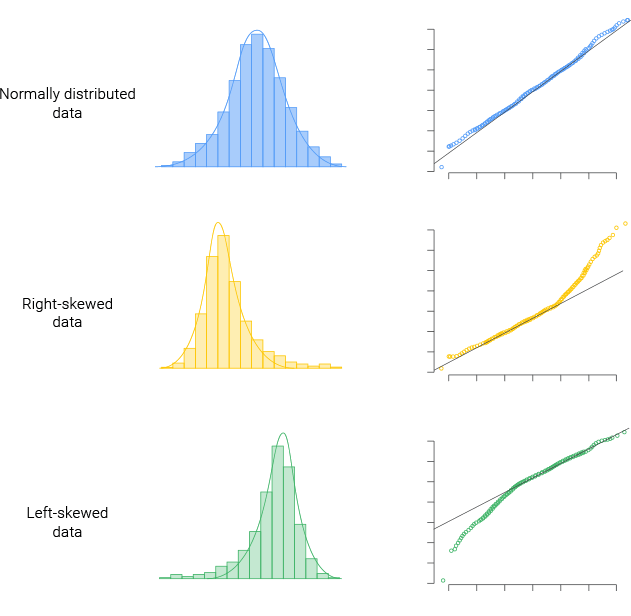

The more the qq plot sticks to the line inclined to 45 degree, the more normal the data is. The pattern of qqplot and the inclined line w.r.t. different type of data is clearly visible.

# Function Transformer


## 1. Log Transform
bada values ko chota kr deta h, additive scale ko multiplicitive scale mein convert kr deta h.

10, 100, 1000 ko 1, 2, 3 mein kr deta h [just an example with log base 10]

-Can't use on -ve values

-Used on right skewed data

## 2. Reciprocal Transform
chota value ko bada value mein convert kr deta h and vice versa. Might work on data that contain a RANGE of values.

## 3. Square Transform
works on left skewed data.

Jo bada values hai usko aur bada kr deta h hence expanding the range of values that are higher.

## 4. SquareRoot Transform
Square root krte hain.

Should work on right skewed data.

Can infere its working from above tranform.

Not mostly used (because log transform is superior?)

In [2]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import  LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [6]:
df = pd.read_csv('drive/MyDrive/Datasets/train.csv',usecols=['Age','Fare','Survived'])

In [7]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [8]:
df.fillna({'Age': df['Age'].mean()},inplace=True)

In [9]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [10]:
X= df.iloc[:,1:]
y= df.iloc[:,0]

In [11]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42)

Text(0.5, 1.0, 'age qq plot')

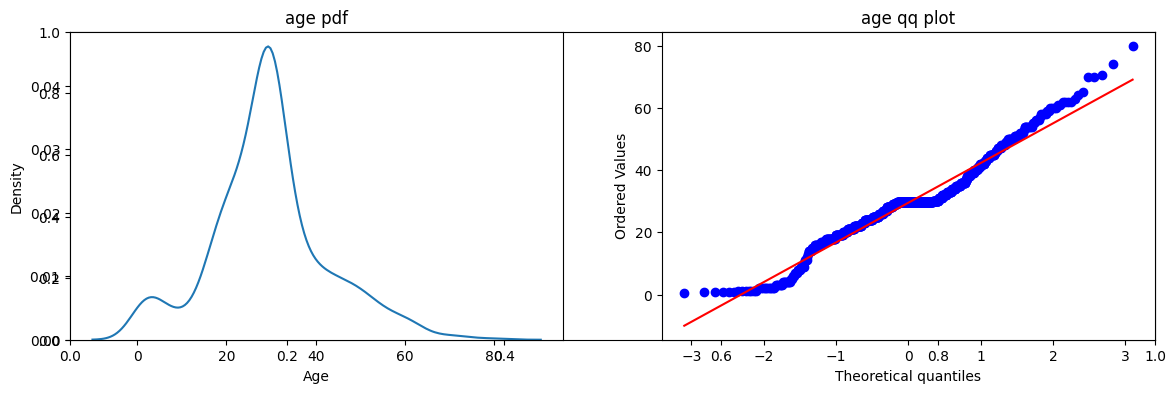

In [16]:
plt.subplots(figsize=(14,4))
plt.subplot(121)
sns.kdeplot(X_train['Age'])
plt.title('age pdf')

plt.subplot(122)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('age qq plot')

Text(0.5, 1.0, 'fare qq plot')

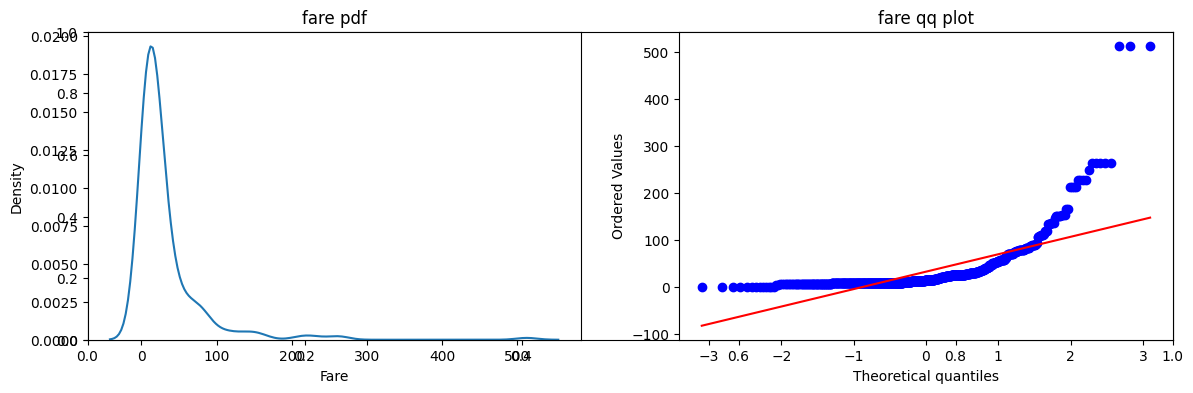

In [17]:
plt.subplots(figsize=(14,4))
plt.subplot(121)
sns.kdeplot(X_train['Fare'])
plt.title('fare pdf')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('fare qq plot')

In [18]:
clfl = LogisticRegression()
clft = DecisionTreeClassifier()

In [24]:
clfl.fit(X_train, y_train)
clft.fit(X_train, y_train)

y_pred_l= clfl.predict(X_test)
y_pred_t= clft.predict(X_test)

print('Accuracy LR', accuracy_score(y_test,y_pred_l))
print('Accuracy DT', accuracy_score(y_test,y_pred_t))

Accuracy LR 0.6480446927374302
Accuracy DT 0.664804469273743


In [25]:
trf= FunctionTransformer(func=np.log1p)

# 1p => 1 plus, it adds 1 to every data so it doesn't have to see zero

In [26]:
X_train_transformed= trf.fit_transform(X_train)
X_test_transformed= trf.transform(X_test)

In [28]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.659217877094972


Clear increase in accuracy of LR

In [31]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_train_transformed,y_train,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_train_transformed,y_train,scoring='accuracy',cv=10)))

LR 0.6783646322378717
DT 0.6235133020344288


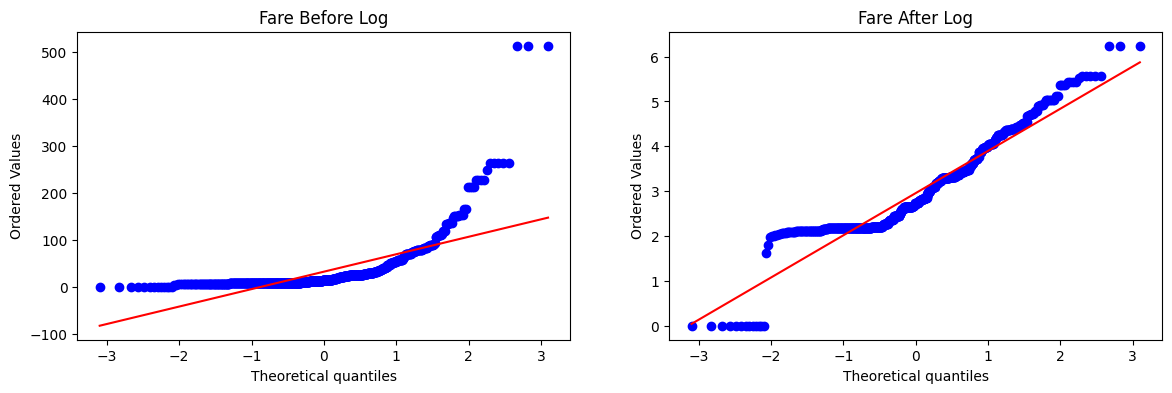

In [32]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

we can see that the fare column data has had an effect. It is more normalized!!

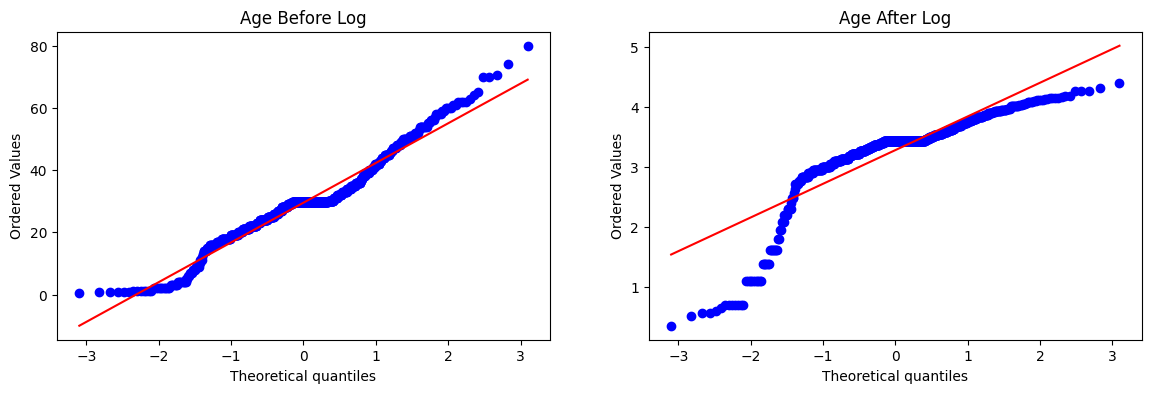

In [33]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

Age has also had some effect but in a negative sense because it is actually worse than before. So we will only apply log transformation to the fare column.

In [34]:
tnf = ColumnTransformer([('log',FunctionTransformer(func=np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2= tnf.fit_transform(X_train)
X_test_transformed2=tnf.transform(X_test)

In [38]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6480446927374302


No effect visible. looks deprecated even :(